*Aprendizaje Profundo*  
*Tarea 5 -*  
*Autor:* Ing. Daniel Eduardo González Alvarado  
*Profesor:* Dr. Sebastian Salazar

# Cargar Libreias

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import random

# Cargar Database

In [3]:
digits = load_digits()
X = digits.data
Y = digits.target
print(X, len(X))
print(Y, len(Y))

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]] 1797
[0 1 2 ... 8 9 8] 1797


# Seleccionar Numeros Aleatorios

In [4]:
digitos = random.sample(range(10), 2)
print("Numeros Aleatorios:", digitos)

X = digits.data
Y = digits.target

Numeros Aleatorios: [5, 2]


# Filtrar Numeros

In [6]:
mask = np.isin(Y, digitos)
X = X[mask]
Y = Y[mask]

In [7]:
Y = (Y == digitos[1]).astype(int)

X = X / 16.0
m, n = X.shape

# Agregar columna de sesgo
X = np.hstack([np.ones((m,1)), X])

# Separar en Entrenamiento y Prueba

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

# Regresion Logistica

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y, y_pred):
    m = len(y)
    
    epsilon = 1e-9
    return -(1/m) * np.sum(y * np.log(y_pred + epsilon) + (1 - y) * np.log(1 - y_pred + epsilon))

def predict(X, theta):
    return sigmoid(np.dot(X, theta))

In [11]:
theta = np.zeros(X_train.shape[1])
alpha = 0.1   # tasa de aprendizaje
epochs = 1000

for epoch in range(epochs):
    y_pred = predict(X_train, theta)
    grad = (1/len(Y_train)) * np.dot(X_train.T, (y_pred - Y_train))
    theta -= alpha * grad
    
    if epoch % 100 == 0:
        loss = compute_loss(Y_train, y_pred)
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.1327
Epoch 200, Loss: 0.0766
Epoch 300, Loss: 0.0553
Epoch 400, Loss: 0.0439
Epoch 500, Loss: 0.0367
Epoch 600, Loss: 0.0317
Epoch 700, Loss: 0.0280
Epoch 800, Loss: 0.0251
Epoch 900, Loss: 0.0228


# Evaluar

In [ ]:
y_test_pred = predict(X_test, theta)
y_test_pred_class = (y_test_pred >= 0.5).astype(int)

# Mapear las etiquetas de los numeros originales
label_map = {0: digitos[0], 1: digitos[1]}
y_test_pred_labels = np.array([label_map[val] for val in y_test_pred_class])
y_test_true_labels = np.array([label_map[val] for val in Y_test])

accuracy = np.mean(y_test_pred_class == Y_test)
print(f"\nExactitud: {accuracy*100:.2f}%")


Exactitud: 100.00%


In [24]:
print("\nMatriz de confusión:")
print(confusion_matrix(Y_test, y_test_pred_class))

print("\nReporte de clasificación:")
print(classification_report(Y_test, y_test_pred_class))


Matriz de confusión:
[[57  0]
 [ 0 51]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        57
           1       1.00      1.00      1.00        51

    accuracy                           1.00       108
   macro avg       1.00      1.00      1.00       108
weighted avg       1.00      1.00      1.00       108



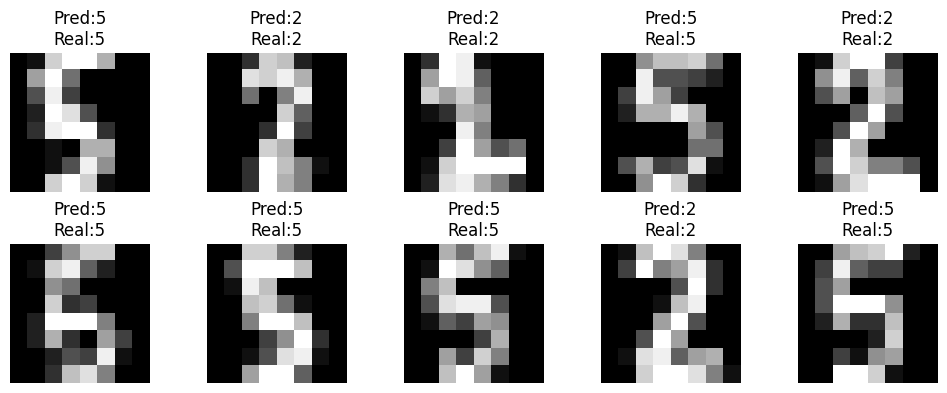

In [25]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i,1:].reshape(8,8), cmap=plt.cm.gray)
    plt.title(f"Pred:{y_test_pred_labels[i]}\nReal:{y_test_true_labels[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()